<a href="https://colab.research.google.com/github/kc-ck/BUS888-Codebase/blob/main/10A_NN_StratComp_Backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PREAMBLE
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt

In [2]:
# Constants
TICKER = "AAPL"
START_DATE = '2021-07-01'
END_DATE = '2026-07-30'
LOOK_BACK = 90
EPOCHS = 50
BATCH_SIZE = 32

INITIAL_BALANCE = 10000  # Initial balance in dollars
TRANSACTION_COST = 0  # Cost per transaction in dollars
MAX_BUY_LIMIT = 100  # Maximum number of stocks to buy per transaction

## FUNCTIONS

In [3]:
def fetch_stock_data(ticker=TICKER, start_date=START_DATE, end_date=END_DATE):
    return yf.download(ticker, start=start_date, end=end_date)


def prepare_data_without_scaling(data, look_back):
    # Preparing data without scaling to avoid data leakage
    close_prices = data['Close'].values.reshape(-1, 1)

    X, y = [], []
    for i in range(look_back, len(close_prices)):
        X.append(close_prices[i - look_back:i, 0])
        y.append(close_prices[i, 0])

    return np.array(X), np.array(y)

def split_data(X, y, ratio=0.8):
    train_size = int(len(X) * ratio)
    return X[:train_size], X[train_size:], y[:train_size], y[train_size:]

def build_model(input_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

def rolling_prediction(model, X_test, look_back, steps_ahead=1):
    test_predictions = []

    for i in range(0, len(X_test) - steps_ahead + 1):
        current_batch = X_test[i].reshape(1, look_back)
        for j in range(steps_ahead):
            current_pred = model.predict(current_batch)[0]
            test_predictions.append(current_pred)

            # Shift the batch left by one step
            current_batch = np.roll(current_batch, -1)

            # If not the last step, insert the predicted value for the next prediction
            if j < steps_ahead - 1:
                current_batch[-1][-1] = current_pred

    return test_predictions

def plot_actual_vs_predicted(actual, predicted, account_values, title):
    """Plot actual vs. predicted stock prices and account values."""
    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Stock prices
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Stock Price', color='tab:blue')
    ax1.plot(actual, label="Actual Prices", color='tab:blue')
    ax1.plot(predicted, label="Predicted Prices", color="red", alpha=0.7)
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Account values (if provided)
    if account_values:
        ax2 = ax1.twinx()
        ax2.set_ylabel('Account Value', color='tab:green')
        ax2.plot(account_values, label="Account Value", color='tab:green', linestyle='--')
        ax2.tick_params(axis='y', labelcolor='tab:green')

    fig.tight_layout()
    plt.title(title)
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.85))
    plt.grid(True)
    plt.show()

## Trading Strategies

Trading Strategy 1 is a simpler strategy where the agent buys or sells a single stock based on whether the predicted next day price is higher or lower than the current day's price.

In [4]:
def trading_strategy1(y_test_original, test_predictions_original):
    balance = INITIAL_BALANCE
    stock_count = 0
    account_values = [INITIAL_BALANCE]
    buy_points, sell_points = [],[]

    for i in range(len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]
        account_value = balance + stock_count * today_price
        account_values.append(account_value)

        print(f"Day {i}, Current Price: {today_price:.2f}, Predicted Price: {predicted_next_day_price:.2f}, "
              f"Stocks: {stock_count}, Account Balance: {balance:.2f}, Account Value: {account_values[i]:.2f}")

        # Buy if predicted price is higher, sell if lower
        if predicted_next_day_price > today_price and balance > today_price and stock_count == 0:
            stock_count += 1
            balance -= today_price
            buy_points.append((i, today_price))
            print(f"Buy: Day {i}, Current Price: {today_price:.2f}, Predicted Price: {predicted_next_day_price:.2f}, "
                  f"Stocks: {stock_count}, Account Balance: {balance:.2f}")

        elif predicted_next_day_price < today_price and stock_count > 0:
            stock_count -= 1
            balance += today_price
            sell_points.append((i, today_price))
            print(f"Sell: Day {i}, Current Price: {today_price:.2f}, Predicted Price: {predicted_next_day_price:.2f}, "
                  f"Stocks: {stock_count}, Account Balance: {balance:.2f}")

    # Sell if stock remaining
    if stock_count >= 1:
        balance += stock_count * y_test_original[-1][0]
        stock_count = 0
    account_values.append(balance)  # add the final account value

    return balance, buy_points, sell_points, account_values

Trading Strategy 2 is a more complex strategy that introduces a MAX_BUY_LIMIT and TRANSACTION_COST. This strategy allows the agent to buy multiple stocks up to the defined limit and considers the cost associated with each transaction when calculating the balance."

In [5]:
def trading_strategy2(y_test_original, test_predictions_original):
    balance = INITIAL_BALANCE
    transaction_cost = TRANSACTION_COST
    max_buy_limit = MAX_BUY_LIMIT
    stock_count = 0
    buy_points, sell_points, account_values = [], [], []

    for i in range(len(y_test_original) - 1):
        today_price = y_test_original[i][0]
        predicted_next_day_price = test_predictions_original[i + 1][0]
        account_value = balance + stock_count * today_price
        account_values.append(account_value)

        # Calculate the number of stocks we can buy
        max_stocks_to_buy = min(max_buy_limit, balance // (today_price + transaction_cost))

        # Buy condition
        if predicted_next_day_price > today_price and max_stocks_to_buy > 0:
            stock_count += max_stocks_to_buy
            balance -= (today_price + transaction_cost) * max_stocks_to_buy
            buy_points.append((i, today_price, max_stocks_to_buy))
            print(f"Buy: Day {i}, Current Price: {today_price}, Predicted Price: {predicted_next_day_price}, "
                  f"Stocks Bought: {max_stocks_to_buy}, Account Balance: {balance}")

        # Sell condition - sell all stocks
        elif predicted_next_day_price < today_price and stock_count > 0:
            balance += (today_price - transaction_cost) * stock_count
            sell_points.append((i, today_price, stock_count))
            print(f"Sell: Day {i}, Current Price: {today_price}, Predicted Price: {predicted_next_day_price}, "
                  f"Stocks Sold: {stock_count}, Account Balance: {balance}")
            stock_count = 0

    # Final balance adjustment if stock is remaining
    if stock_count > 0:
        balance += y_test_original[-1][0] * stock_count
        stock_count = 0
    account_values.append(balance)

    return balance, buy_points, sell_points, account_values

## MAIN

In [6]:
# Fetch and prepare data
data = fetch_stock_data()
X, y = prepare_data_without_scaling(data, LOOK_BACK)
X_train, X_test, y_train, y_test = split_data(X, y)

/tmp/ipykernel_2185/4278830810.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [7]:
# Scaling the data
scaler_X = MinMaxScaler(feature_range=(0, 1))
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))

In [8]:
# Train model
model = build_model(LOOK_BACK)
model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0131
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0046
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0032
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0025
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0021
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0020
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0016
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0026
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0021
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014
Epoch 16

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


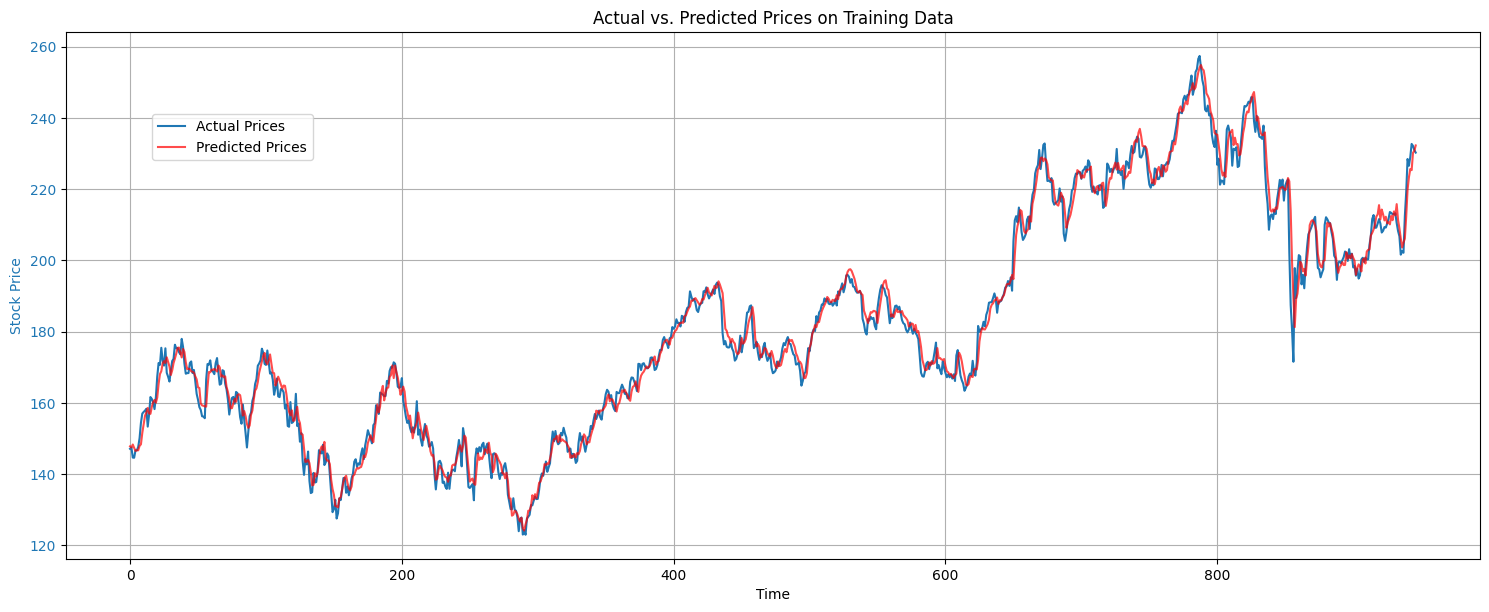

In [9]:
# Inverse transform the data back to original scale and plot
y_train_original = scaler_y.inverse_transform(y_train)
train_predictions = model.predict(X_train)
train_predictions_original = scaler_y.inverse_transform(train_predictions)

plot_actual_vs_predicted(y_train_original, train_predictions_original, None, "Actual vs. Predicted Prices on Training Data")

In [10]:
# Test the model
test_predictions = rolling_prediction(model, X_test, LOOK_BACK)
test_predictions_original = scaler_y.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━

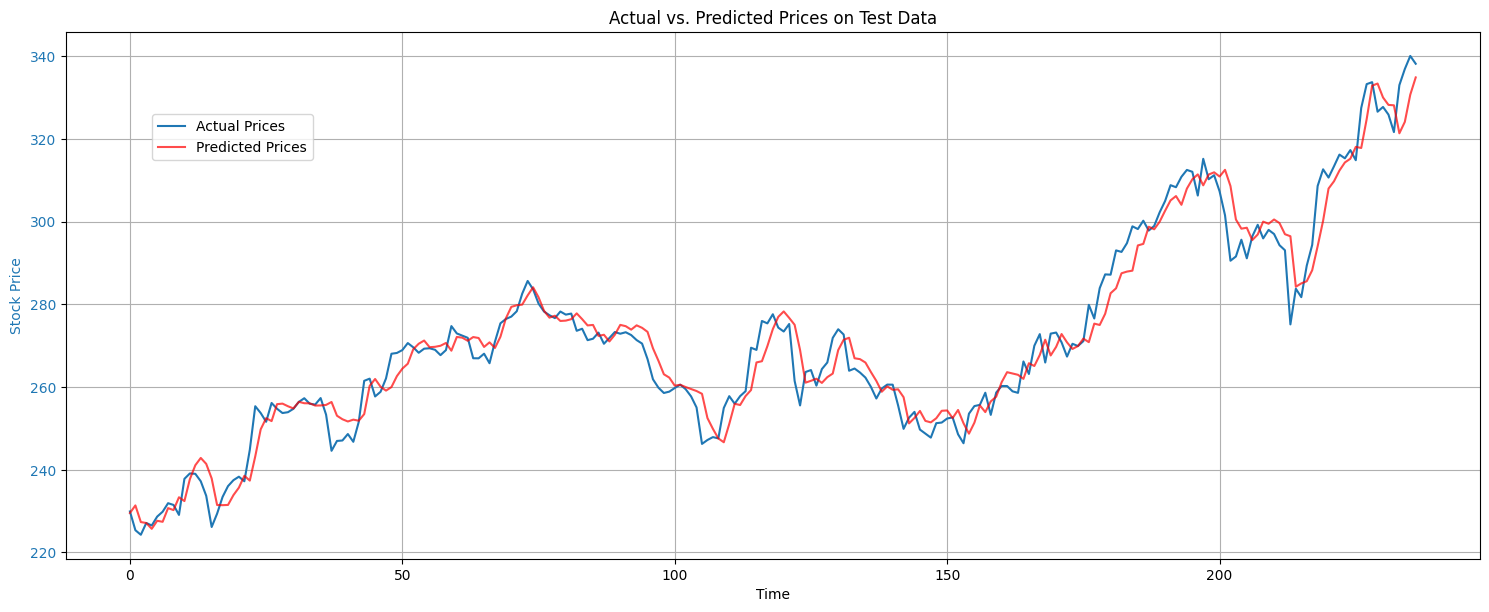

In [11]:
#Plot Actual vs predict for test data
plot_actual_vs_predicted(y_test_original, test_predictions_original, None, "Actual vs. Predicted Prices on Test Data")

Day 0, Current Price: 229.91, Predicted Price: 231.37, Stocks: 0, Account Balance: 10000.00, Account Value: 10000.00
Buy: Day 0, Current Price: 229.91, Predicted Price: 231.37, Stocks: 1, Account Balance: 9770.09
Day 1, Current Price: 225.37, Predicted Price: 227.35, Stocks: 1, Account Balance: 9770.09, Account Value: 10000.00
Day 2, Current Price: 224.27, Predicted Price: 227.11, Stocks: 1, Account Balance: 9770.09, Account Value: 9995.46
Day 3, Current Price: 227.12, Predicted Price: 225.70, Stocks: 1, Account Balance: 9770.09, Account Value: 9994.36
Sell: Day 3, Current Price: 227.12, Predicted Price: 225.70, Stocks: 0, Account Balance: 9997.21
Day 4, Current Price: 226.52, Predicted Price: 227.65, Stocks: 0, Account Balance: 9997.21, Account Value: 9997.21
Buy: Day 4, Current Price: 226.52, Predicted Price: 227.65, Stocks: 1, Account Balance: 9770.69
Day 5, Current Price: 228.66, Predicted Price: 227.41, Stocks: 1, Account Balance: 9770.69, Account Value: 9997.21
Sell: Day 5, Curre

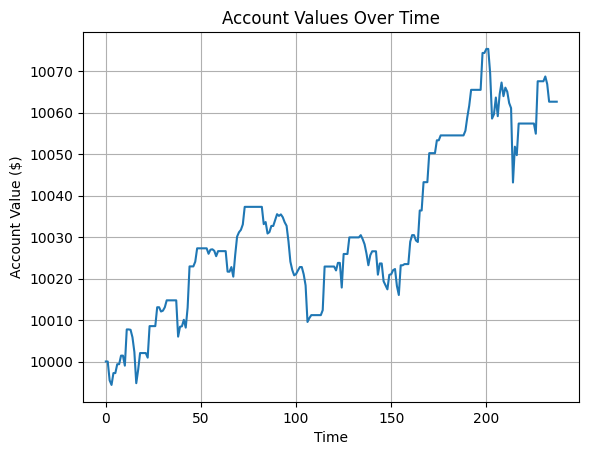

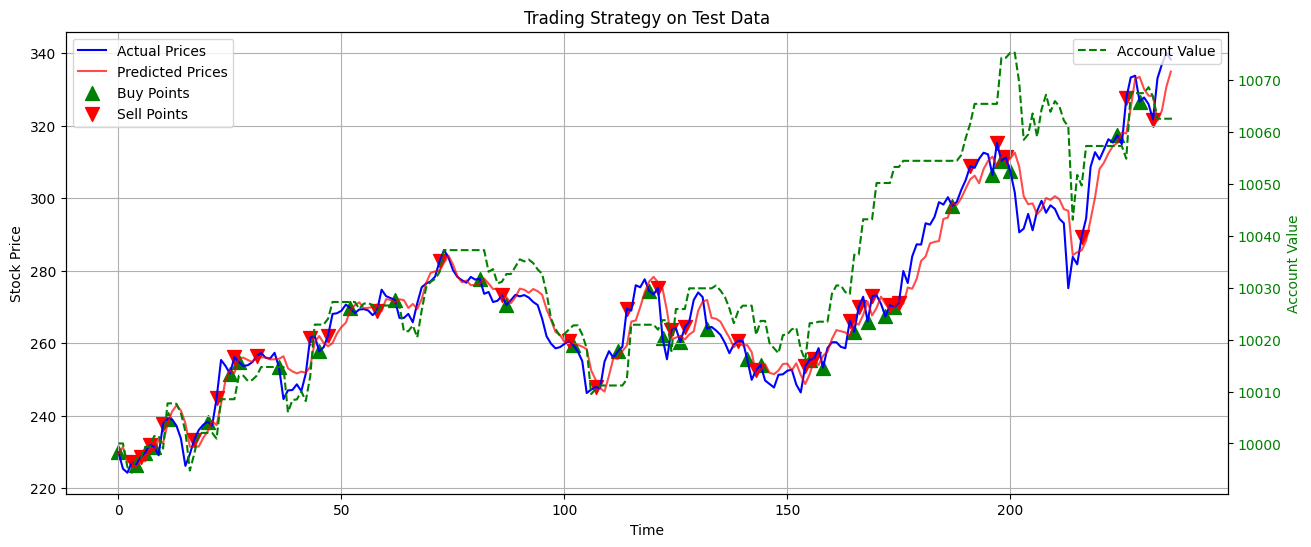

In [12]:
# Implement trading strategy 1 and plot results
balance1, buy_points1, sell_points1, account_values1 = trading_strategy1(y_test_original, test_predictions_original)
print(f"Final Balance: {balance1}")
plt.plot(account_values1)
plt.title('Account Values Over Time')
plt.xlabel('Time')
plt.ylabel('Account Value ($)')
plt.grid(True)
plt.show()

# Plot results
buy_indices, buy_prices, = zip(*buy_points1) if buy_points1 else ([], [], []) # _ is used to discard the third element
sell_indices, sell_prices, = zip(*sell_points1) if sell_points1 else ([], [], [])

plt.figure(figsize=(15, 6))
ax1 = plt.gca()  # get current axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax1.plot(y_test_original, label="Actual Prices", color="blue")
ax1.plot(test_predictions_original, label="Predicted Prices", color="red", alpha=0.7)
ax1.scatter(buy_indices, buy_prices, color="green", marker="^", alpha=1, label="Buy Points", s=100)
ax1.scatter(sell_indices, sell_prices, color="red", marker="v", alpha=1, label="Sell Points", s=100)
ax1.set_title("Trading Strategy on Test Data")
ax1.set_xlabel("Time")
ax1.set_ylabel("Stock Price")
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(account_values1, label="Account Value", color="green", linestyle='--')
ax2.set_ylabel("Account Value", color="green")
ax2.tick_params(axis='y', labelcolor="green")
ax2.legend(loc='upper right')

plt.show()

Buy: Day 0, Current Price: 229.90956115722656, Predicted Price: 231.36705017089844, Stocks Bought: 43.0, Account Balance: 113.88887023925781
Sell: Day 3, Current Price: 227.11746215820312, Predicted Price: 225.70260620117188, Stocks Sold: 43.0, Account Balance: 9879.939743041992
Buy: Day 4, Current Price: 226.5191650390625, Predicted Price: 227.6492919921875, Stocks Bought: 43.0, Account Balance: 139.6156463623047
Sell: Day 5, Current Price: 228.6630859375, Predicted Price: 227.40574645996094, Stocks Sold: 43.0, Account Balance: 9972.128341674805
Buy: Day 6, Current Price: 229.8397674560547, Predicted Price: 230.71337890625, Stocks Bought: 43.0, Account Balance: 89.01834106445312
Sell: Day 7, Current Price: 231.9039306640625, Predicted Price: 230.2411651611328, Stocks Sold: 43.0, Account Balance: 10060.88735961914
Buy: Day 8, Current Price: 231.485107421875, Predicted Price: 233.34130859375, Stocks Bought: 43.0, Account Balance: 107.02774047851562
Sell: Day 10, Current Price: 237.79725

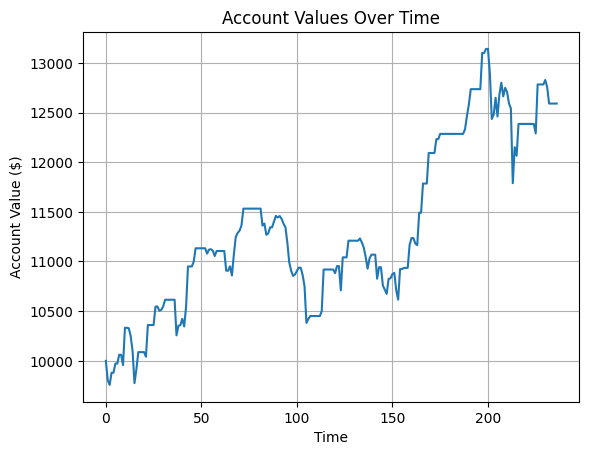

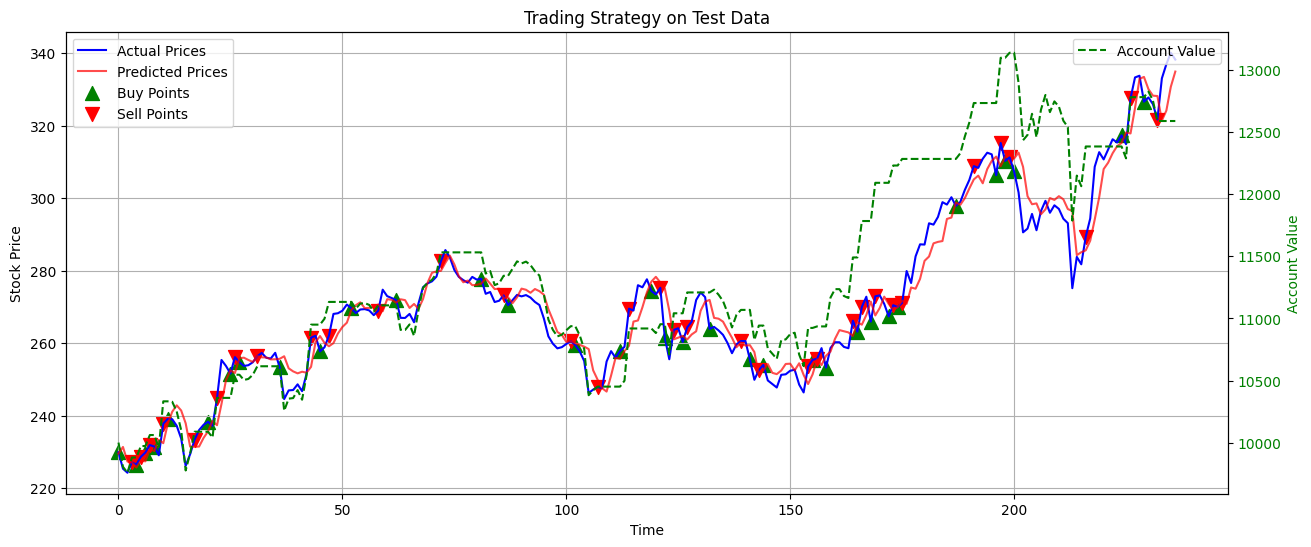

In [13]:
# Implement trading strategy 2 and plot results
balance2, buy_points2, sell_points2, account_values2 = trading_strategy2(y_test_original, test_predictions_original)
print(f"Final Balance: {balance2}")
plt.plot(account_values2)
plt.title('Account Values Over Time')
plt.xlabel('Time')
plt.ylabel('Account Value ($)')
plt.grid(True)
plt.show()

# Plot results
buy_indices2, buy_prices2, *_ = zip(*buy_points2) if buy_points2 else ([], [], [])  # Use *_ to capture extra values
sell_indices2, sell_prices2, *_ = zip(*sell_points2) if sell_points2 else ([], [], [])

plt.figure(figsize=(15, 6))
ax1 = plt.gca()  # get current axis
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax1.plot(y_test_original, label="Actual Prices", color="blue")
ax1.plot(test_predictions_original, label="Predicted Prices", color="red", alpha=0.7)
ax1.scatter(buy_indices2, buy_prices2, color="green", marker="^", alpha=1, label="Buy Points", s=100)
ax1.scatter(sell_indices2, sell_prices2, color="red", marker="v", alpha=1, label="Sell Points", s=100)
ax1.set_title("Trading Strategy on Test Data")
ax1.set_xlabel("Time")
ax1.set_ylabel("Stock Price")
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(account_values2, label="Account Value", color="green", linestyle='--')
ax2.set_ylabel("Account Value", color="green")
ax2.tick_params(axis='y', labelcolor="green")
ax2.legend(loc='upper right')

plt.show()

## BAcktest

In [14]:
def calculate_performance(account_values, risk_free_rate=0.03):
    # Calculate total return
    total_return = (account_values[-1] - account_values[0]) / account_values[0] * 100

    # Calculate annualized return
    num_years = (len(account_values) / 252)
    annualized_return = (account_values[-1] / account_values[0])**(1 / num_years) - 1

    # Calculate CAGR (Compound Annual Growth Rate)
    cagr = (account_values[-1] / account_values[0])**(1 / num_years) - 1

    # Calculate MDD (Maximum Drawdown)
    running_max = np.maximum.accumulate(account_values)
    drawdown = (account_values - running_max) / running_max
    max_drawdown = drawdown.min()

    # Calculate daily returns
    daily_returns = np.diff(account_values) / account_values[:-1]

    # Calculate Volatility (annualized standard deviation of daily returns)
    volatility = np.std(daily_returns) * np.sqrt(252)

    # Calculate Sharpe Ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / volatility

    return {
        "total_return": total_return,
        "annualized_return": annualized_return,
        "cagr": cagr,
        "max_drawdown": max_drawdown,
        "volatility": volatility,
        "sharpe_ratio": sharpe_ratio,
    }


In [15]:
# Calculate performance for both strategies
performance1 = calculate_performance(account_values1)
performance2 = calculate_performance(account_values2)

# Print the results
print("Strategy 1 Performance:")
for metric, value in performance1.items():
    print(f"{metric}: {value:.2f}%")

print("\nStrategy 2 Performance:")
for metric, value in performance2.items():
    print(f"{metric}: {value:.2f}%")


Strategy 1 Performance:
total_return: 0.63%
annualized_return: 0.01%
cagr: 0.01%
max_drawdown: -0.00%
volatility: 0.01%
sharpe_ratio: -4.65%

Strategy 2 Performance:
total_return: 25.90%
annualized_return: 0.28%
cagr: 0.28%
max_drawdown: -0.10%
volatility: 0.19%
sharpe_ratio: 1.33%



Strategy 2 outperformed Strategy 1 in terms of total return.
Strategy 1 Final Balance: 10062.60
Strategy 2 Final Balance: 12590.17


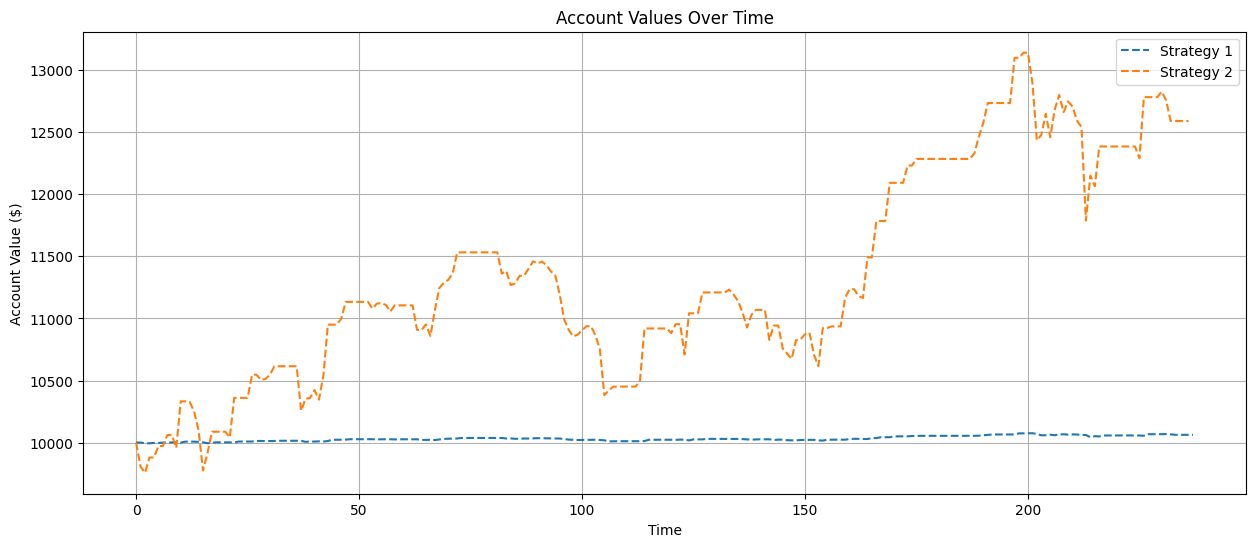

In [16]:
# Compare the performance of both strategies
if performance1["total_return"] > performance2["total_return"]:
    print("\nStrategy 1 outperformed Strategy 2 in terms of total return.")
elif performance1["total_return"] < performance2["total_return"]:
    print("\nStrategy 2 outperformed Strategy 1 in terms of total return.")
else:
    print("\nBoth strategies had the same total return.")

# Print results
print(f"Strategy 1 Final Balance: {balance1:.2f}")
print(f"Strategy 2 Final Balance: {balance2:.2f}")

# Plot account values for both strategies
plt.figure(figsize=(15, 6))
plt.plot(account_values1, label="Strategy 1", linestyle='--')
plt.plot(account_values2, label="Strategy 2", linestyle='--')
plt.title('Account Values Over Time')
plt.xlabel('Time')
plt.ylabel('Account Value ($)')
plt.grid(True)
plt.legend()
plt.show()